In [2]:
#import statements
import numpy as np
import rebound
import matplotlib.pyplot as plt
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
from tqdm import tqdm
import heyoka as hy
from scipy import signal
import sympy as sp
import time

from hk_integrator import hk_integrate, ft, pomega_ft, get_pomega, get_ecc

In [3]:
#constants
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

## Direct N-Body (WHFast) Graphs

In [3]:
########################### TEST PARTICLE CASE ###################################3

sim_test_n_body = rebound.Simulation()
sim_test_n_body.add(m=1, hash = "Sun")
sim_test_n_body.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_test_n_body.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_test_n_body.move_to_com()

sat = sim_test_n_body.particles[2]
jup = sim_test_n_body.particles[1]

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat_test_n_body = np.zeros(len(times))
e_sat_test_n_body = np.zeros(len(times))
a_sat_test_n_body = np.zeros(len(times))
p_sat_test_n_body = np.zeros(len(times))

long_peri_j_test_n_body = np.zeros(len(times))
e_j_test_n_body = np.zeros(len(times))
a_j_test_n_body = np.zeros(len(times))
p_j_test_n_body = np.zeros(len(times))

sim_test_n_body.init_megno()
e_i = sim_test_n_body.energy()

for i in tqdm(range(len(times))):
    sim_test_n_body.integrate(times[i])
    
    long_peri_sat_test_n_body[i] = sat.pomega
    e_sat_test_n_body[i] = sat.e
    a_sat_test_n_body[i] = sat.a
    p_sat_test_n_body[i] = sat.P

    long_peri_j_test_n_body[i] = jup.pomega
    e_j_test_n_body[i] = jup.e
    a_j_test_n_body[i] = jup.a
    p_j_test_n_body[i] = jup.P
    
e_f = sim_test_n_body.energy()
m_f = sim_test_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2e}')

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [01:17<00:00, 1294.04it/s]

Energy percent change:  5.49e-13 %
Final MEGNO value:  2.12e+02


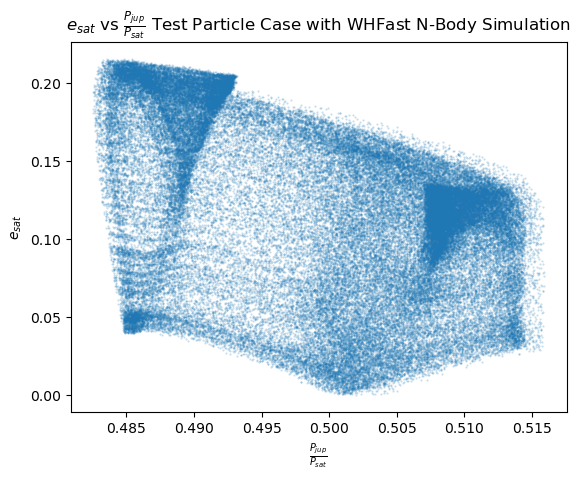

In [11]:
# e_sat vs period ratio graph

plt.title(r'$e_{sat}$ vs $\frac{P_{jup}}{P_{sat}}$ Test Particle Case with WHFast N-Body Simulation')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$\frac{P_{jup}}{P_{sat}}$')
plt.scatter(p_j_test_n_body/p_sat_test_n_body, e_sat_test_n_body, s = 0.25, alpha = 0.25)

top_axis = plt.gca().twiny()


plt.show()

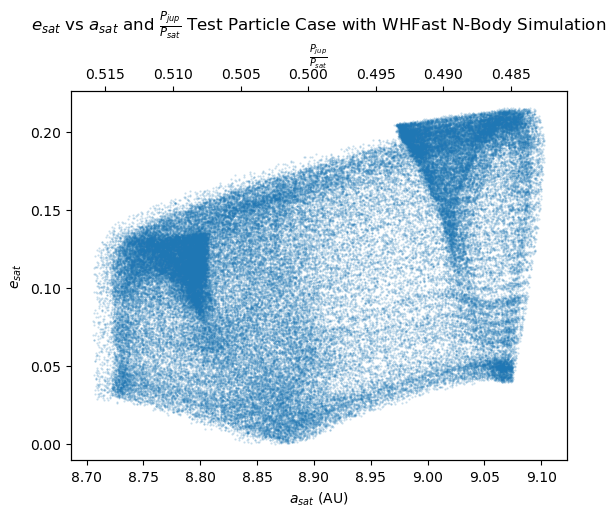

In [46]:
# e_sat vs a_sat graph
plt.title(r'$e_{sat}$ vs $a_{sat}$ and $\frac{P_{jup}}{P_{sat}}$ Test Particle Case with WHFast N-Body Simulation')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$a_{sat}$ (AU)')
plt.scatter(a_sat_test_n_body, e_sat_test_n_body, s = 0.25, alpha = 0.25)

top_axis = plt.gca().twiny()

top_axis.set_xlabel(r'$\frac{P_{jup}}{P_{sat}}$')
top_axis.scatter(p_j_test_n_body/p_sat_test_n_body, e_sat_test_n_body, s = 0, alpha = 0)
top_axis.invert_xaxis()
plt.show()

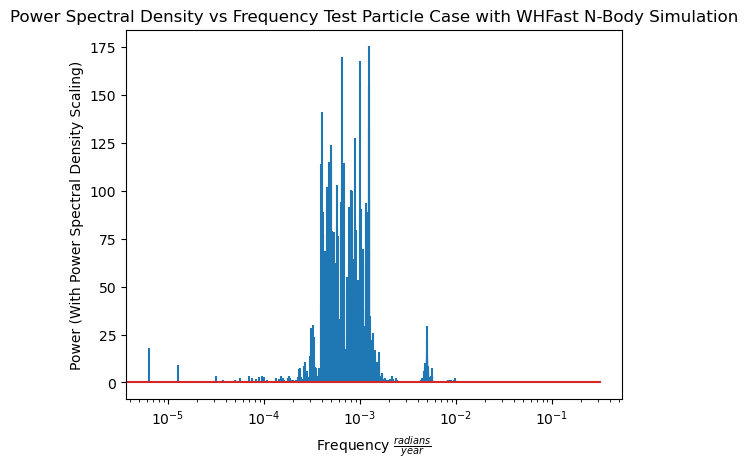

In [4]:
#fourier transform
f,pxx = pomega_ft(times, long_peri_sat_test_n_body, e_sat_test_n_body)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with WHFast N-Body Simulation')
plt.show()

In [5]:
############### MASSIVE CASE #########################################
sim_full_n_body = rebound.Simulation()
sim_full_n_body.add(m=1, hash = "Sun")
sim_full_n_body.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_full_n_body.add(m=m_sat,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_full_n_body.move_to_com()

sat = sim_full_n_body.particles[2]
jup = sim_full_n_body.particles[1]

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat_full_n_body = np.zeros(len(times))
e_sat_full_n_body = np.zeros(len(times))
a_sat_full_n_body = np.zeros(len(times))
p_sat_full_n_body = np.zeros(len(times))

long_peri_j_full_n_body = np.zeros(len(times))
e_j_full_n_body = np.zeros(len(times))
a_j_full_n_body = np.zeros(len(times))
p_j_full_n_body = np.zeros(len(times))

sim_full_n_body.init_megno()
e_i_full_n_body = sim_full_n_body.energy()

for i in tqdm(range(len(times))):
    sim_full_n_body.integrate(times[i])
    
    long_peri_sat_full_n_body[i] = sat.pomega
    e_sat_full_n_body[i] = sat.e
    a_sat_full_n_body[i] = sat.a
    p_sat_full_n_body[i] = sat.P

    long_peri_j_full_n_body[i] = jup.pomega
    e_j_full_n_body[i] = jup.e
    a_j_full_n_body[i] = jup.a
    p_j_full_n_body[i] = jup.P

e_f = sim_full_n_body.energy()
m_f = sim_full_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2e}')

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [01:32<00:00, 1081.91it/s]

Energy percent change:  1.82e+01 %
Final MEGNO value:  2.46e+02


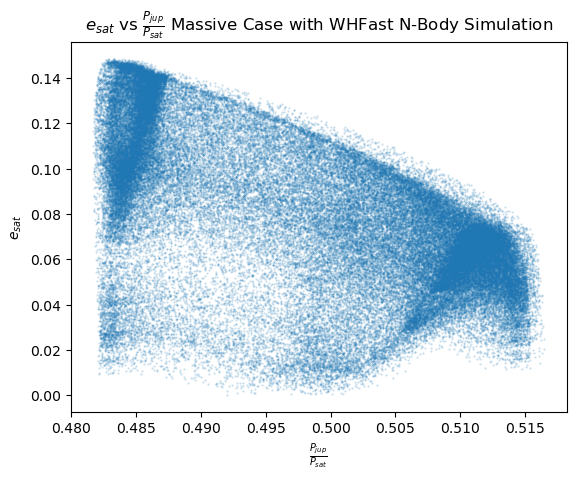

In [21]:
# e_sat vs period ratio graph

plt.title(r'$e_{sat}$ vs $\frac{P_{jup}}{P_{sat}}$ Massive Case with WHFast N-Body Simulation')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$\frac{P_{jup}}{P_{sat}}$')
plt.scatter(p_j_full_n_body/p_sat_full_n_body, e_sat_full_n_body, s = 0.25, alpha = 0.25)
plt.show()

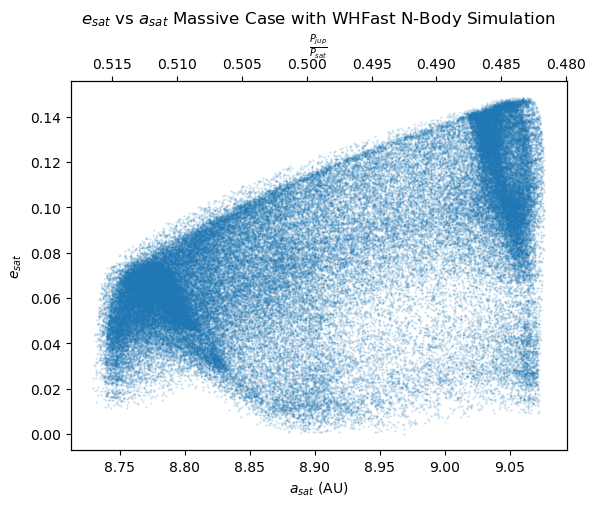

In [49]:
# e_sat vs a_sat graph
plt.title(r'$e_{sat}$ vs $a_{sat}$ Massive Case with WHFast N-Body Simulation')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$a_{sat}$ (AU)')
plt.scatter(a_sat_full_n_body, e_sat_full_n_body, s = 0.25, alpha = 0.25)

top_axis = plt.gca().twiny()

top_axis.set_xlabel(r'$\frac{P_{jup}}{P_{sat}}$')
plt.scatter(p_j_full_n_body/p_sat_full_n_body, e_sat_full_n_body, s = 0, alpha = 0)D
top_axis.invert_xaxis()

plt.show()

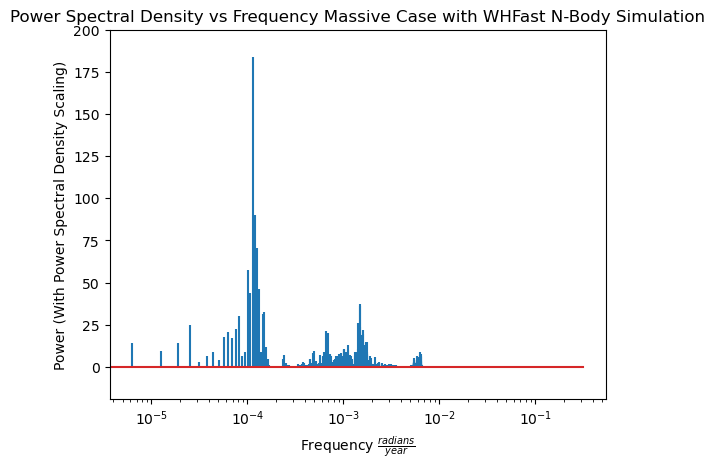

In [10]:
#fourier transform
f,pxx = pomega_ft(times, long_peri_sat_full_n_body, e_sat_full_n_body)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Massive Case with WHFast N-Body Simulation')
plt.ylim(top=200)
plt.show()

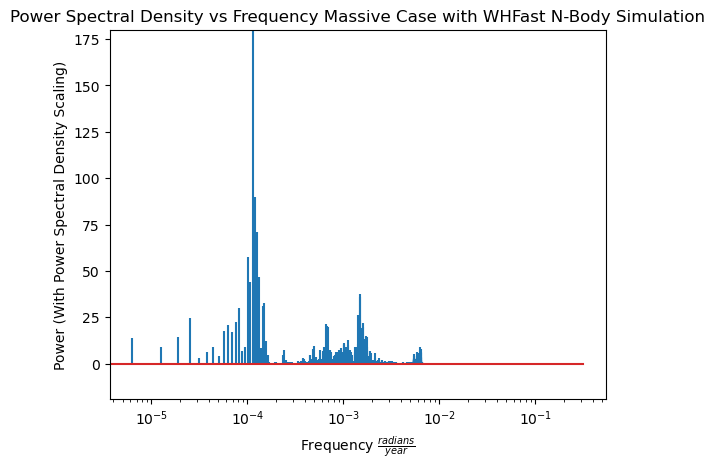

In [9]:
#fourier transform
f,pxx = pomega_ft(times, long_peri_sat_full_n_body, e_sat_full_n_body)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Massive Case with WHFast N-Body Simulation')
plt.ylim(top=180)
plt.show()

## Poincare Hamiltonian (Celmech)

In [12]:
############## FIRST ORDER MMR ################################

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham_1st_ord_MMR = PoincareHamiltonian(pvars)
pham_1st_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_1st_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1) 



times, pomega_sat_1st_ord_MMR, pomega_j_1st_ord_MMR, e_sat_1st_ord_MMR, a_sat_1st_ord_MMR, a_jup_1st_ord_MMR, lam_sat,lam_jup = hk_integrate(pham_1st_ord_MMR, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634816146e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:10<00:00, 9532.26it/s]

-8.880166634815167e-05
Energy Percent Change: 1.1018852470986615e-11 %
*** Simulation Complete ***
Time elapsed  = 10.496867860999828 seconds


In [1]:
# e_sat vs period ratio graph

plt.title(r'$e_{sat}$ vs $\frac{P_{jup}}{P_{sat}}$ Test Particle Case 1st Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$\frac{P_{jup}}{P_{sat}}$')
plt.scatter(np.sqrt(a_jup_1st_ord_MMR**3)/np.sqrt(a_sat_1st_ord_MMR**3), e_sat_1st_ord_MMR, s = 0.25, alpha = 0.25)
plt.show()

NameError: name 'plt' is not defined

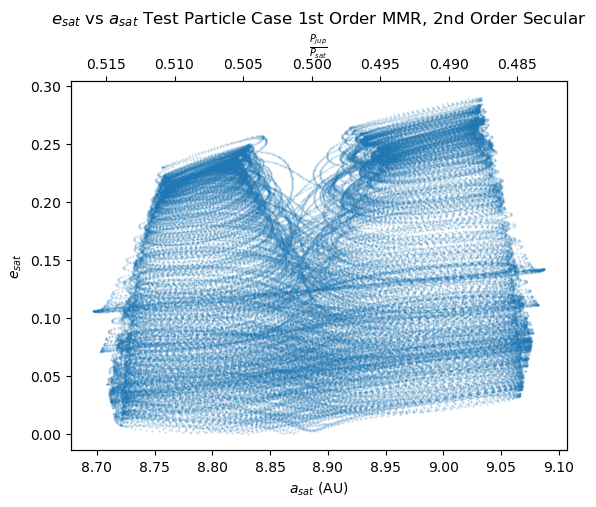

In [52]:
# e_sat vs a_sat graph
plt.title(r'$e_{sat}$ vs $a_{sat}$ Test Particle Case 1st Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$a_{sat}$ (AU)')
plt.scatter(a_sat_1st_ord_MMR, e_sat_1st_ord_MMR, s = 0.25, alpha = 0.25)

top_axis = plt.gca().twiny()

top_axis.set_xlabel(r'$\frac{P_{jup}}{P_{sat}}$')
plt.scatter(np.sqrt(a_jup_1st_ord_MMR**3)/np.sqrt(a_sat_1st_ord_MMR**3), e_sat_1st_ord_MMR, s = 0, alpha = 0)
top_axis.invert_xaxis()

plt.show()

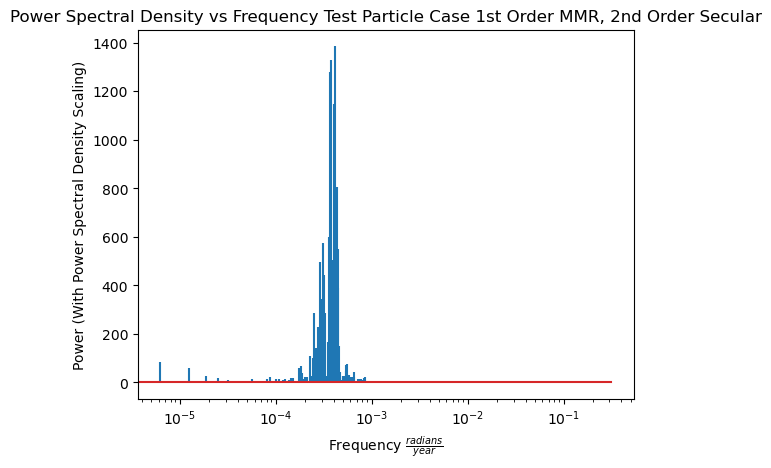

In [13]:
#fourier transform
f,pxx = pomega_ft(times, pomega_sat_1st_ord_MMR, e_sat_1st_ord_MMR)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case 1st Order MMR, 2nd Order Secular')
plt.show()

In [14]:
#################### SECOND ORDER MMR ###########################
pham_2dn_ord_MMR = PoincareHamiltonian(pvars)
pham_2dn_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_2dn_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

times, pomega_sat_2dn_ord_MMR, pomega_j_2dn_ord_MMR, e_sat_2dn_ord_MMR, a_sat_2dn_ord_MMR, a_jup_2dn_ord_MMR, lam_sat,lam_jup = hk_integrate(pham_2dn_ord_MMR, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634823682e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:12<00:00, 7907.19it/s]

-8.880166634822883e-05
Energy Percent Change: 9.004325426421863e-12 %
*** Simulation Complete ***
Time elapsed  = 12.650780943999962 seconds


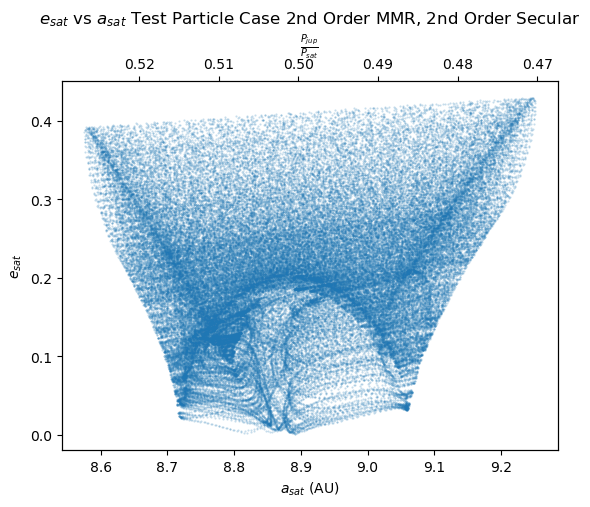

In [66]:
# e_sat vs a_sat graph
plt.title(r'$e_{sat}$ vs $a_{sat}$ Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$a_{sat}$ (AU)')
plt.scatter(a_sat_2dn_ord_MMR, e_sat_2dn_ord_MMR, s = 0.25, alpha = 0.25)

top_axis = plt.gca().twiny()

top_axis.set_xlabel(r'$\frac{P_{jup}}{P_{sat}}$')
plt.scatter(np.sqrt(a_jup_2dn_ord_MMR**3)/np.sqrt(a_sat_2dn_ord_MMR**3), e_sat_2dn_ord_MMR, s = 0, alpha = 0)
top_axis.invert_xaxis()

plt.show()

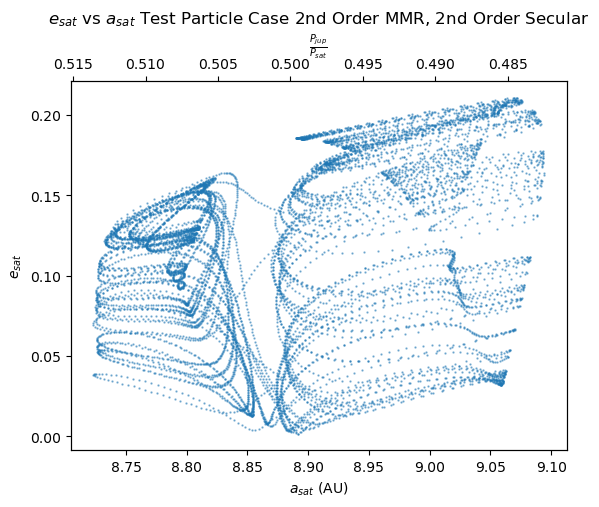

In [65]:
#shorter time period
# e_sat vs a_sat graph
plt.title(r'$e_{sat}$ vs $a_{sat}$ Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$a_{sat}$ (AU)')
plt.scatter(a_sat_2dn_ord_MMR[0:int(1e4)], e_sat_2dn_ord_MMR[0:int(1e4)], s = 0.5, alpha = 0.5)

top_axis = plt.gca().twiny()

top_axis.set_xlabel(r'$\frac{P_{jup}}{P_{sat}}$')
plt.scatter(np.sqrt(a_jup_2dn_ord_MMR[0:int(1e4)]**3)/np.sqrt(a_sat_2dn_ord_MMR[0:int(1e4)]**3), e_sat_2dn_ord_MMR[0:int(1e4)], s = 0, alpha = 0)
top_axis.invert_xaxis()

plt.show()

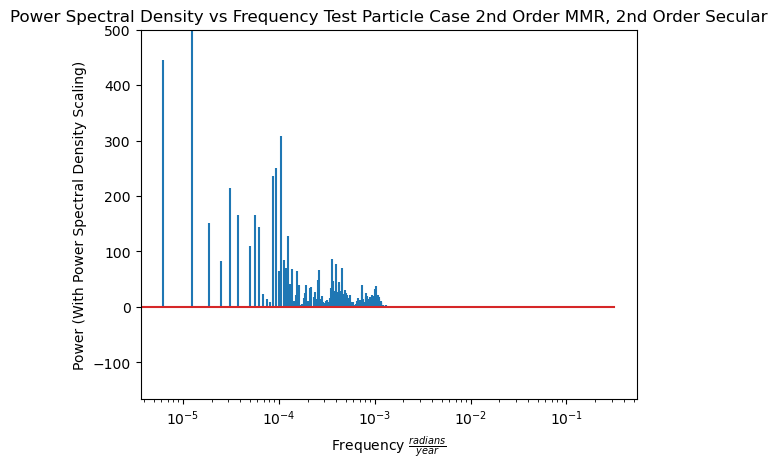

In [16]:
#fourier transform
f,pxx = pomega_ft(times, pomega_sat_2dn_ord_MMR, e_sat_2dn_ord_MMR)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylim(top = 500)
plt.show()

In [18]:
##################### THIRD ORDER MMR ####################################
pham_3rd_ord_MMR = PoincareHamiltonian(pvars)
pham_3rd_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_3rd_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=3) 

times, pomega_sat_3rd_ord_MMR, pomega_j_3rd_ord_MMR, e_sat_3rd_ord_MMR, a_sat_3rd_ord_MMR, a_jup_3rd_ord_MMR, sat_lam, jup_lam = hk_integrate(pham_3rd_ord_MMR, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634824185e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:23<00:00, 4196.69it/s]

-8.880166634822767e-05
Energy Percent Change: 1.5963600671248704e-11 %
*** Simulation Complete ***
Time elapsed  = 23.8319219240002 seconds


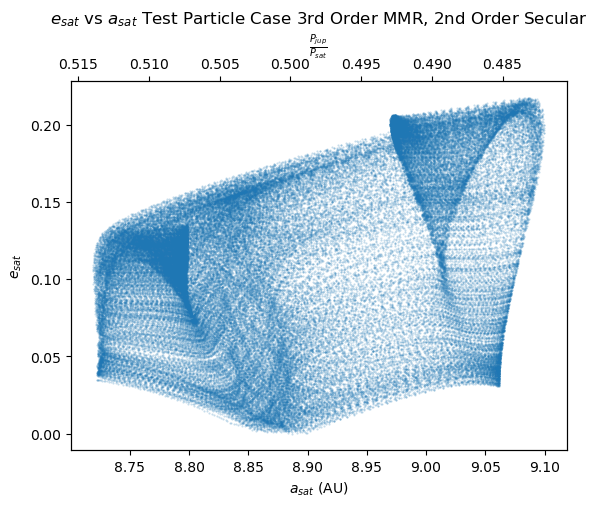

In [64]:
plt.title(r'$e_{sat}$ vs $a_{sat}$ Test Particle Case 3rd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$a_{sat}$ (AU)')
plt.scatter(a_sat_3rd_ord_MMR, e_sat_3rd_ord_MMR, s = 0.25, alpha = 0.25)

top_axis = plt.gca().twiny()

top_axis.set_xlabel(r'$\frac{P_{jup}}{P_{sat}}$')
plt.scatter(np.sqrt(a_jup_3rd_ord_MMR**3)/np.sqrt(a_sat_3rd_ord_MMR**3), e_sat_3rd_ord_MMR, s = 0, alpha = 0)
top_axis.invert_xaxis()

plt.show()

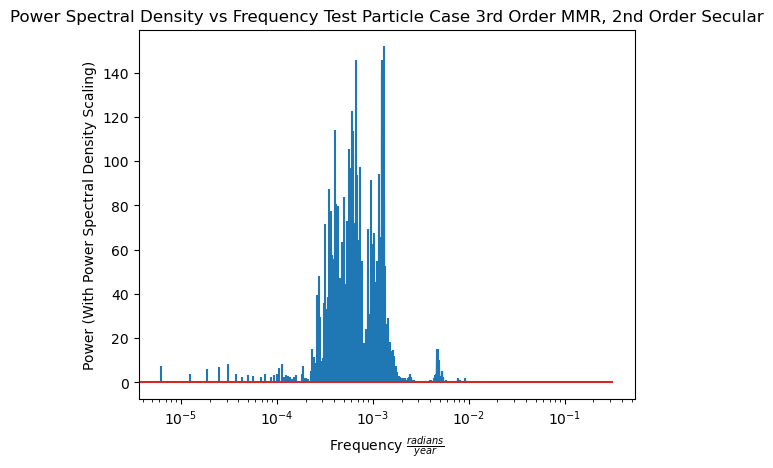

In [19]:
#fourier transform
f,pxx = pomega_ft(times, pomega_sat_3rd_ord_MMR, e_sat_3rd_ord_MMR)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case 3rd Order MMR, 2nd Order Secular')
plt.show()

In [20]:
########################### FOURTH ORDER MMR ##############################
pham_4th_ord_MMR = PoincareHamiltonian(pvars)
pham_4th_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_4th_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4) 

times, pomega_sat_4th_ord_MMR, pomega_j_4th_ord_MMR, e_sat_4th_ord_MMR, a_sat_4th_ord_MMR, a_jup_4th_ord_MMR, lam_sat, lam_j = hk_integrate(pham_4th_ord_MMR, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634824106e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:52<00:00, 1892.98it/s]

-8.88016663482396e-05
Energy Percent Change: 1.6482494000907031e-12 %
*** Simulation Complete ***
Time elapsed  = 52.830930500999784 seconds


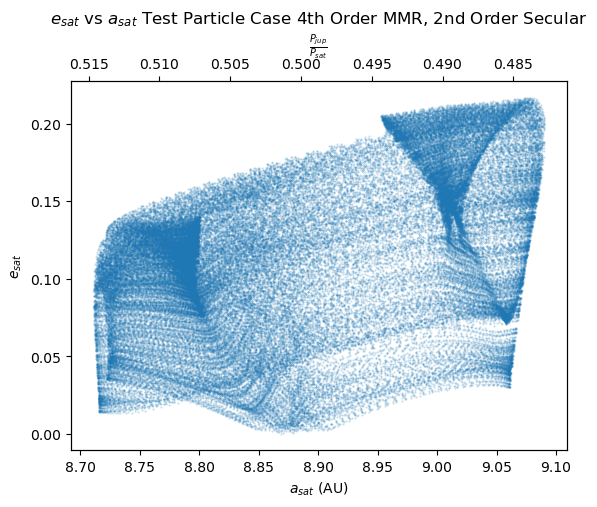

In [71]:
plt.title(r'$e_{sat}$ vs $a_{sat}$ Test Particle Case 4th Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$a_{sat}$ (AU)')
plt.scatter(a_sat_4th_ord_MMR, e_sat_4th_ord_MMR, s = 0.25, alpha = 0.25)

top_axis = plt.gca().twiny()

top_axis.set_xlabel(r'$\frac{P_{jup}}{P_{sat}}$')
plt.scatter(np.sqrt(a_jup_4th_ord_MMR**3)/np.sqrt(a_sat_4th_ord_MMR**3), e_sat_4th_ord_MMR, s = 0, alpha = 0)
top_axis.invert_xaxis()

plt.show()

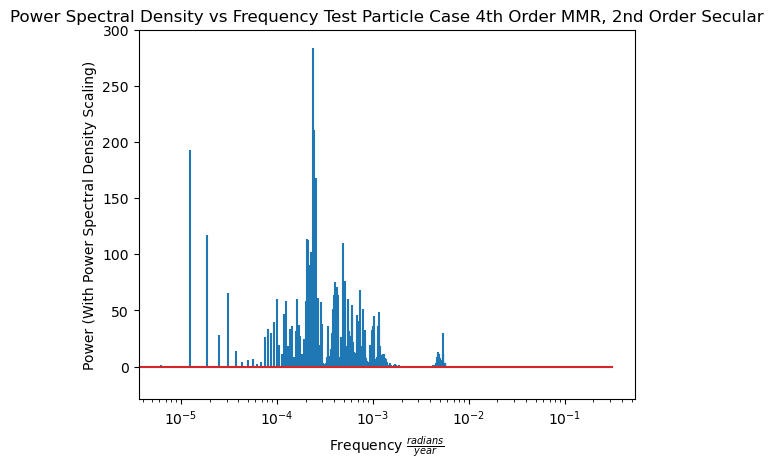

In [24]:
#fourier transform
f,pxx = pomega_ft(times, pomega_sat_4th_ord_MMR, e_sat_4th_ord_MMR)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case 4th Order MMR, 2nd Order Secular')
plt.ylim(top=300)
plt.show()

In [4]:
#sample rate testing

########################### TEST PARTICLE CASE ###################################3

sim_test_n_body = rebound.Simulation()
sim_test_n_body.add(m=1, hash = "Sun")
sim_test_n_body.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_test_n_body.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_test_n_body.move_to_com()

sat = sim_test_n_body.particles[2]
jup = sim_test_n_body.particles[1]

times = np.linspace(0,1e6,int(1e6))*2*np.pi
long_peri_sat_test_n_body = np.zeros(len(times))
e_sat_test_n_body = np.zeros(len(times))
a_sat_test_n_body = np.zeros(len(times))
p_sat_test_n_body = np.zeros(len(times))

long_peri_j_test_n_body = np.zeros(len(times))
e_j_test_n_body = np.zeros(len(times))
a_j_test_n_body = np.zeros(len(times))
p_j_test_n_body = np.zeros(len(times))

sim_test_n_body.init_megno()
e_i = sim_test_n_body.energy()

for i in tqdm(range(len(times))):
    sim_test_n_body.integrate(times[i])
    
    long_peri_sat_test_n_body[i] = sat.pomega
    e_sat_test_n_body[i] = sat.e
    a_sat_test_n_body[i] = sat.a
    p_sat_test_n_body[i] = sat.P

    long_peri_j_test_n_body[i] = jup.pomega
    e_j_test_n_body[i] = jup.e
    a_j_test_n_body[i] = jup.a
    p_j_test_n_body[i] = jup.P
    
e_f = sim_test_n_body.energy()
m_f = sim_test_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2e}')

100%|███████████████████████████████████████████████████████████████████████| 1000000/1000000 [02:46<00:00, 6021.63it/s]

Energy percent change:  3.40e-12 %
Final MEGNO value:  2.53e+02


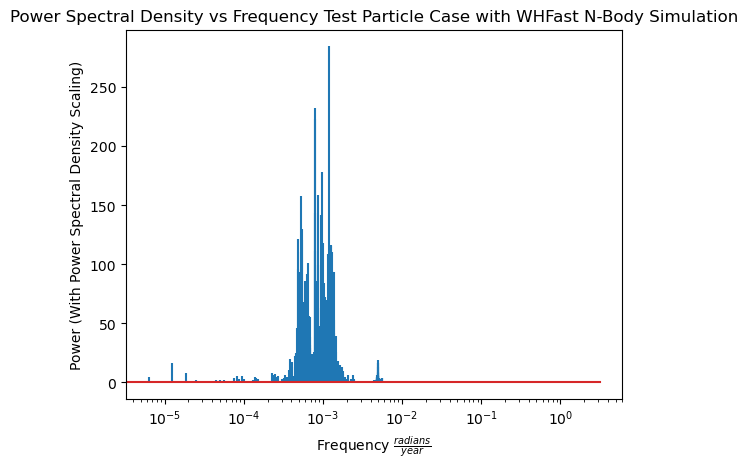

In [5]:
#fourier transform
f,pxx = pomega_ft(times, long_peri_sat_test_n_body, e_sat_test_n_body)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with WHFast N-Body Simulation')
plt.show()

In [9]:
#sample rate testing

########################### TEST PARTICLE CASE ###################################3

sim_test_n_body = rebound.Simulation()
sim_test_n_body.add(m=1, hash = "Sun")
sim_test_n_body.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_test_n_body.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_test_n_body.move_to_com()

sat = sim_test_n_body.particles[2]
jup = sim_test_n_body.particles[1]

times = np.linspace(0,1e6,int(1e4))*2*np.pi
long_peri_sat_test_n_body = np.zeros(len(times))
e_sat_test_n_body = np.zeros(len(times))
a_sat_test_n_body = np.zeros(len(times))
p_sat_test_n_body = np.zeros(len(times))

long_peri_j_test_n_body = np.zeros(len(times))
e_j_test_n_body = np.zeros(len(times))
a_j_test_n_body = np.zeros(len(times))
p_j_test_n_body = np.zeros(len(times))

sim_test_n_body.init_megno()
e_i = sim_test_n_body.energy()

for i in tqdm(range(len(times))):
    sim_test_n_body.integrate(times[i])
    
    long_peri_sat_test_n_body[i] = sat.pomega
    e_sat_test_n_body[i] = sat.e
    a_sat_test_n_body[i] = sat.a
    p_sat_test_n_body[i] = sat.P

    long_peri_j_test_n_body[i] = jup.pomega
    e_j_test_n_body[i] = jup.e
    a_j_test_n_body[i] = jup.a
    p_j_test_n_body[i] = jup.P
    
e_f = sim_test_n_body.energy()
m_f = sim_test_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2e}')

100%|████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:41<00:00, 239.22it/s]

Energy percent change:  3.66e-12 %
Final MEGNO value:  2.52e+02


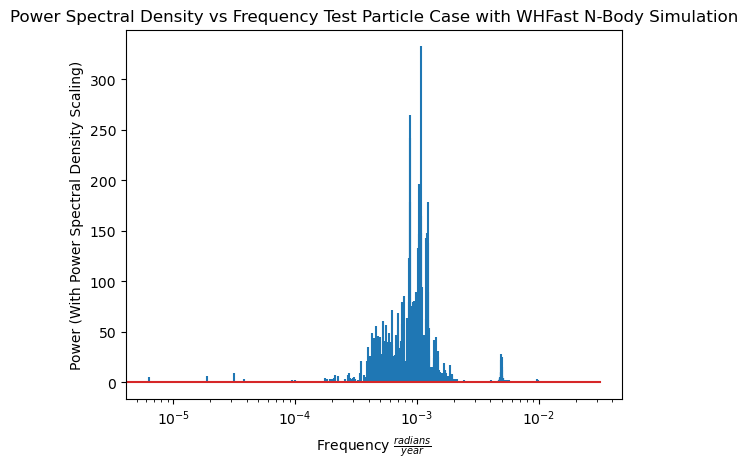

In [10]:
#fourier transform
f,pxx = pomega_ft(times, long_peri_sat_test_n_body, e_sat_test_n_body)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with WHFast N-Body Simulation')
plt.show()